In [ ]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import EfficientNet_B0_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


# CONFIGURATION


DATASET_ROOT = Path(
    r"C:\major-project\model\dataset"
)

MODEL_DIR = Path(
    r"C:\major-project\model\models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("APPLE FRESHNESS MODEL")
print("=" * 60)

print("Dataset:", DATASET_ROOT)
print("Dataset exists:", DATASET_ROOT.exists())

print("Model directory:", MODEL_DIR)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print("=" * 60)

APPLE FRESHNESS MODEL
Dataset: C:\major-project\model\dataset
Dataset exists: True
Model directory: C:\major-project\model\models
Device: cpu


In [ ]:
# LOAD APPLE DATASET

TRAIN_ROOT = DATASET_ROOT / "train"
TEST_ROOT = DATASET_ROOT / "test"

CLASS_NAMES = [
    "fresh",
    "rotten"
]

CLASS_TO_LABEL = {
    "freshapples": 0,
    "rottenapples": 1
}


def collect_images(root):

    image_paths = []
    labels = []

    for folder_name, label in CLASS_TO_LABEL.items():

        class_dir = root / folder_name

        if not class_dir.exists():

            raise FileNotFoundError(
                f"Folder not found: {class_dir}"
            )

        for file in class_dir.iterdir():

            if file.suffix.lower() in [
                ".jpg",
                ".jpeg",
                ".png",
                ".bmp",
                ".webp"
            ]:

                image_paths.append(
                    str(file)
                )

                labels.append(label)

    return image_paths, labels


# Load training images

all_train_paths, all_train_labels = collect_images(
    TRAIN_ROOT
)


# Load test images

test_paths, test_labels = collect_images(
    TEST_ROOT
)


# Display dataset statistics

print("\nDATASET INFORMATION")
print("-" * 60)

print(
    "Total training images:",
    len(all_train_paths)
)

print(
    "Fresh training:",
    all_train_labels.count(0)
)

print(
    "Rotten training:",
    all_train_labels.count(1)
)

print()

print(
    "Total test images:",
    len(test_paths)
)

print(
    "Fresh test:",
    test_labels.count(0)
)

print(
    "Rotten test:",
    test_labels.count(1)
)


# SPLIT ONLY TRAIN DATA

X_train, X_val, y_train, y_val = train_test_split(

    all_train_paths,
    all_train_labels,

    test_size=0.20,

    random_state=42,

    stratify=all_train_labels
)


print("\nFINAL SPLIT")
print("-" * 60)

print(
    "Training:",
    len(X_train)
)

print(
    "Validation:",
    len(X_val)
)

print(
    "Testing:",
    len(test_paths)
)


DATASET INFORMATION
------------------------------------------------------------
Total training images: 4035
Fresh training: 1693
Rotten training: 2342

Total test images: 996
Fresh test: 395
Rotten test: 601

FINAL SPLIT
------------------------------------------------------------
Training: 3228
Validation: 807
Testing: 996


In [ ]:
# IMAGE TRANSFORMS

train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=15
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


test_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# DATASET CLASS

class AppleDataset(Dataset):

    def __init__(
        self,
        image_paths,
        labels,
        transform=None
    ):

        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, index):

        image_path = self.image_paths[index]

        label = self.labels[index]

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform is not None:

            image = self.transform(
                image
            )

        return image, label


# CREATE DATASETS

train_dataset = AppleDataset(
    X_train,
    y_train,
    train_transform
)

val_dataset = AppleDataset(
    X_val,
    y_val,
    test_transform
)

test_dataset = AppleDataset(
    test_paths,
    test_labels,
    test_transform
)


# DATA LOADERS

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=torch.cuda.is_available()
)


# VERIFY DATA

images, labels = next(
    iter(train_loader)
)

print("\nDATALOADER CHECK")
print("-" * 60)

print(
    "Image batch shape:",
    images.shape
)

print(
    "Label batch shape:",
    labels.shape
)

print(
    "First labels:",
    labels[:10].tolist()
)


DATALOADER CHECK
------------------------------------------------------------
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First labels: [1, 1, 1, 0, 1, 1, 1, 1, 1, 1]


In [22]:
# LOAD PRETRAINED EFFICIENTNET-B0

weights = EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(
    weights=weights
)


# REPLACE CLASSIFICATION HEAD

num_features = (
    model.classifier[1].in_features
)

model.classifier[1] = nn.Linear(
    num_features,
    2
)


# Move model to GPU/CPU
model = model.to(DEVICE)


# 
# LOSS + OPTIMIZER

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)


# TRAINING FUNCTIONS

def train_one_epoch():

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0


    for images, labels in train_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        optimizer.zero_grad()


        outputs = model(
            images
        )


        loss = criterion(
            outputs,
            labels
        )


        loss.backward()

        optimizer.step()


        running_loss += (
            loss.item()
            * images.size(0)
        )


        predictions = outputs.argmax(
            dim=1
        )


        correct += (
            predictions == labels
        ).sum().item()


        total += labels.size(0)


    loss = running_loss / total

    accuracy = correct / total

    return loss, accuracy


def validate():

    model.eval()

    running_loss = 0.0

    correct = 0

    total = 0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )


            outputs = model(
                images
            )


            loss = criterion(
                outputs,
                labels
            )


            running_loss += (
                loss.item()
                * images.size(0)
            )


            predictions = outputs.argmax(
                dim=1
            )


            correct += (
                predictions == labels
            ).sum().item()


            total += labels.size(0)


    loss = running_loss / total

    accuracy = correct / total

    return loss, accuracy


# TRAINING LOOP

best_val_accuracy = 0.0

history = {

    "train_loss": [],

    "train_accuracy": [],

    "val_loss": [],

    "val_accuracy": []

}


MODEL_PATH = (
    MODEL_DIR /
    "apple_efficientnet_b0_best.pth"
)


for epoch in range(EPOCHS):

    train_loss, train_accuracy = (
        train_one_epoch()
    )

    val_loss, val_accuracy = (
        validate()
    )


    history[
        "train_loss"
    ].append(
        train_loss
    )

    history[
        "train_accuracy"
    ].append(
        train_accuracy
    )

    history[
        "val_loss"
    ].append(
        val_loss
    )

    history[
        "val_accuracy"
    ].append(
        val_accuracy
    )


    print(
        f"\nEpoch "
        f"{epoch + 1}/{EPOCHS}"
    )

    print(
        f"Train Loss: "
        f"{train_loss:.4f}"
    )

    print(
        f"Train Accuracy: "
        f"{train_accuracy * 100:.2f}%"
    )

    print(
        f"Validation Loss: "
        f"{val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: "
        f"{val_accuracy * 100:.2f}%"
    )


    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = (
            val_accuracy
        )


        torch.save(

            {
                "model_state_dict":
                    model.state_dict(),

                "class_names":
                    CLASS_NAMES,

                "val_accuracy":
                    val_accuracy,

                "image_size":
                    IMAGE_SIZE
            },

            MODEL_PATH
        )


        print(
            ">>> Best model saved:",
            MODEL_PATH
        )


print("\n" + "=" * 60)

print(
    "TRAINING COMPLETE"
)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    "Model saved at:",
    MODEL_PATH
)

print("=" * 60)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\kiran/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:06<00:00, 3.24MB/s]



Epoch 1/10
Train Loss: 0.1516
Train Accuracy: 96.10%
Validation Loss: 0.0178
Validation Accuracy: 99.75%
>>> Best model saved: C:\major-project\model\models\apple_efficientnet_b0_best.pth

Epoch 2/10
Train Loss: 0.0274
Train Accuracy: 99.35%
Validation Loss: 0.0067
Validation Accuracy: 99.75%

Epoch 3/10
Train Loss: 0.0157
Train Accuracy: 99.69%
Validation Loss: 0.0022
Validation Accuracy: 100.00%
>>> Best model saved: C:\major-project\model\models\apple_efficientnet_b0_best.pth

Epoch 4/10
Train Loss: 0.0088
Train Accuracy: 99.81%
Validation Loss: 0.0013
Validation Accuracy: 100.00%

Epoch 5/10
Train Loss: 0.0065
Train Accuracy: 99.81%
Validation Loss: 0.0030
Validation Accuracy: 99.88%

Epoch 6/10
Train Loss: 0.0071
Train Accuracy: 99.88%
Validation Loss: 0.0007
Validation Accuracy: 100.00%

Epoch 7/10
Train Loss: 0.0030
Train Accuracy: 99.88%
Validation Loss: 0.0003
Validation Accuracy: 100.00%

Epoch 8/10
Train Loss: 0.0022
Train Accuracy: 99.97%
Validation Loss: 0.0002
Validation


FINAL TEST RESULTS
Test Accuracy: 100.00%

Classification Report
              precision    recall  f1-score   support

       Fresh     1.0000    1.0000    1.0000       395
      Rotten     1.0000    1.0000    1.0000       601

    accuracy                         1.0000       996
   macro avg     1.0000    1.0000    1.0000       996
weighted avg     1.0000    1.0000    1.0000       996



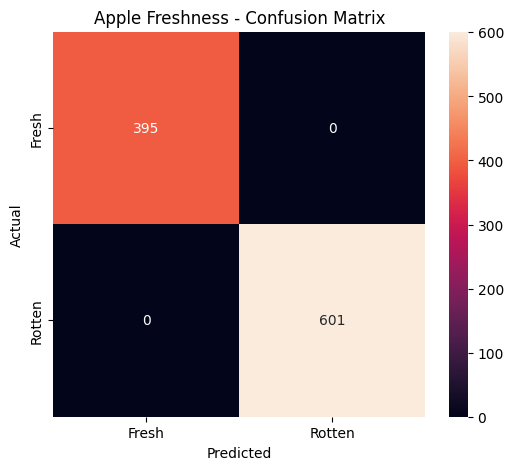

In [23]:
# LOAD BEST MODEL

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()


# TEST PREDICTIONS

all_predictions = []

all_actual = []


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            DEVICE
        )

        outputs = model(
            images
        )

        predictions = outputs.argmax(
            dim=1
        )


        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_actual.extend(
            labels.numpy()
        )


# METRICS

test_accuracy = accuracy_score(
    all_actual,
    all_predictions
)

print("\n" + "=" * 60)

print("FINAL TEST RESULTS")

print("=" * 60)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)


print("\nClassification Report")

print(
    classification_report(
        all_actual,
        all_predictions,
        target_names=[
            "Fresh",
            "Rotten"
        ],
        digits=4
    )
)


# 
# CONFUSION MATRIX

cm = confusion_matrix(
    all_actual,
    all_predictions
)


plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Fresh",
        "Rotten"
    ],
    yticklabels=[
        "Fresh",
        "Rotten"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Apple Freshness - Confusion Matrix"
)

plt.show()

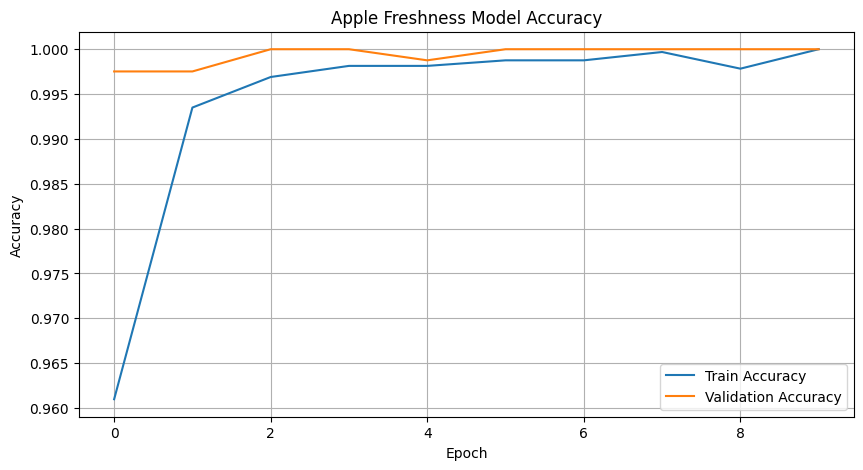

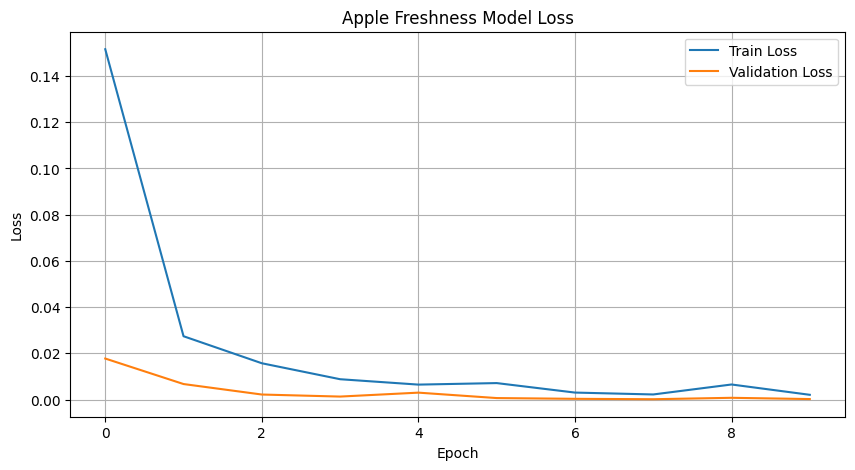


MODEL INFORMATION
Architecture: EfficientNet-B0
Classes: Fresh, Rotten
Best Validation Accuracy: 100.00%
Final Test Accuracy: 100.00%
Saved Model:
C:\major-project\model\models\apple_efficientnet_b0_best.pth


In [24]:
# TRAINING CURVES

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Apple Freshness Model Accuracy"
)

plt.legend()

plt.grid()

plt.show()


# LOSS CURVE

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Apple Freshness Model Loss"
)

plt.legend()

plt.grid()

plt.show()


# FINAL MODEL INFORMATION

print("\n" + "=" * 60)

print("MODEL INFORMATION")

print("=" * 60)

print(
    "Architecture: EfficientNet-B0"
)

print(
    "Classes: Fresh, Rotten"
)

print(
    f"Best Validation Accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    f"Final Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    "Saved Model:"
)

print(
    MODEL_PATH
)

print("=" * 60)